In [1]:
import mrich
import pandas as pd
import plotly.express as px
from mrich import print

In [18]:
data = [
	dict(cycle="xx01zvns2b-01", value=337, method="XChem Hits", type="Structures"),
	
	dict(cycle="xx01zvns2b-01", value=98444, method="Fragmenstein Pure", type="Placement Attempts"),
	dict(cycle="xx01zvns2b-01", value=72617, method="Fragmenstein Pure", type="Unique Compounds"),
	dict(cycle="xx01zvns2b-01", value=25000, method="Fragmenstein Pure", type="Compounds w/ Placements"),
	dict(cycle="xx01zvns2b-01", value=2825, method="Fragmenstein Pure", type="Filtered Scaffolds"),

	dict(cycle="xx01zvns2b-01", value=140608, method="Knitwork Pure", type="Placement Attempts"),
	dict(cycle="xx01zvns2b-01", value=33788, method="Knitwork Pure", type="Unique Compounds"),
	dict(cycle="xx01zvns2b-01", value=15000, method="Knitwork Pure", type="Compounds w/ Placements"),
	dict(cycle="xx01zvns2b-01", value=411, method="Knitwork Pure", type="Filtered Scaffolds"),

	dict(cycle="xx01zvns2b-01", value=146763, method="Knitwork Impure", type="Placement Attempts"),
	dict(cycle="xx01zvns2b-01", value=26774, method="Knitwork Impure", type="Unique Compounds"),
	dict(cycle="xx01zvns2b-01", value=12000, method="Knitwork Impure", type="Compounds w/ Placements"),
	dict(cycle="xx01zvns2b-01", value=378, method="Knitwork Impure", type="Filtered Scaffolds"),


    
	dict(cycle="a71ev2a-01", value=645, method="XChem Hits", type="Structures"),

	dict(cycle="a71ev2a-01", value=306598, method="Fragmenstein Pure", type="Placement Attempts"),
	dict(cycle="a71ev2a-01", value=168303, method="Fragmenstein Pure", type="Unique Compounds"),
	dict(cycle="a71ev2a-01", value=61000, method="Fragmenstein Pure", type="Compounds w/ Placements"),
	dict(cycle="a71ev2a-01", value=309, method="Fragmenstein Pure", type="Filtered Scaffolds"),

	dict(cycle="a71ev2a-01", value=1616879, method="Knitwork Pure", type="Placement Attempts"),
	dict(cycle="a71ev2a-01", value=89045, method="Knitwork Pure", type="Unique Compounds"),
	dict(cycle="a71ev2a-01", value=30000, method="Knitwork Pure", type="Compounds w/ Placements"),
	dict(cycle="a71ev2a-01", value=396, method="Knitwork Pure", type="Filtered Scaffolds"),
	
	dict(cycle="a71ev2a-01", value=1870052, method="Knitwork Impure", type="Placement Attempts"),
	dict(cycle="a71ev2a-01", value=62735, method="Knitwork Impure", type="Unique Compounds"),
	dict(cycle="a71ev2a-01", value=22000, method="Knitwork Impure", type="Compounds w/ Placements"),
	dict(cycle="a71ev2a-01", value=813, method="Knitwork Impure", type="Filtered Scaffolds"),



	dict(cycle="d68ev3c-01", value=228, method="XChem Hits", type="Structures"),

	dict(cycle="d68ev3c-01", value=6356, method="Fragmenstein Pure", type="Placement Attempts"),
	dict(cycle="d68ev3c-01", value=4829, method="Fragmenstein Pure", type="Unique Compounds"),
	dict(cycle="d68ev3c-01", value=1665, method="Fragmenstein Pure", type="Compounds w/ Placements"),
	dict(cycle="d68ev3c-01", value=153, method="Fragmenstein Pure", type="Filtered Scaffolds"),

	dict(cycle="d68ev3c-01", value=268518, method="Knitwork Pure", type="Placement Attempts"),
	dict(cycle="d68ev3c-01", value=58416, method="Knitwork Pure", type="Unique Compounds"),
	dict(cycle="d68ev3c-01", value=19000, method="Knitwork Pure", type="Compounds w/ Placements"),
	dict(cycle="d68ev3c-01", value=83, method="Knitwork Pure", type="Filtered Scaffolds"),
	
	dict(cycle="d68ev3c-01", value=285885, method="Knitwork Impure", type="Placement Attempts"),
	dict(cycle="d68ev3c-01", value=43631, method="Knitwork Impure", type="Unique Compounds"),
	dict(cycle="d68ev3c-01", value=12000, method="Knitwork Impure", type="Compounds w/ Placements"),
	dict(cycle="d68ev3c-01", value=109, method="Knitwork Impure", type="Filtered Scaffolds"),
]


In [19]:
df = pd.DataFrame(data)
df.head()

,cycle,value,method,type
0,xx01zvns2b-01,337,XChem Hits,Structures
1,xx01zvns2b-01,98444,Fragmenstein Pure,Placement Attempts
2,xx01zvns2b-01,72617,Fragmenstein Pure,Unique Compounds
3,xx01zvns2b-01,25000,Fragmenstein Pure,Compounds w/ Placements
4,xx01zvns2b-01,2825,Fragmenstein Pure,Filtered Scaffolds


In [17]:
extra = []

for cycle in set(df["cycle"].values):

    # sums

    sdf = df[df["cycle"] == cycle]

    for t in set(df["type"].values):
        s = sdf[sdf["type"] == t]["value"].sum()

        extra.append(dict(type=t, value=s, cycle=cycle, method="All"))

df = pd.concat([df, pd.DataFrame(extra)])
df

,cycle,value,method,type
0,xx01zvns2b-01,337,XChem Hits,Structures
1,xx01zvns2b-01,98444,Fragmenstein Pure,Placement Attempts
2,xx01zvns2b-01,72617,Fragmenstein Pure,Unique Compounds
3,xx01zvns2b-01,25000,Fragmenstein Pure,Compounds w/ Placements
4,xx01zvns2b-01,2825,Fragmenstein Pure,Filtered Scaffolds
...,...,...,...,...
10,xx01zvns2b-01,266358,All,Unique Compounds
11,xx01zvns2b-01,7228,All,Filtered Scaffolds
12,xx01zvns2b-01,771630,All,Placement Attempts
13,xx01zvns2b-01,674,All,Structures


In [32]:
for cycle in set(df["cycle"].values):
    print("###", cycle)
    sdf = df[df["cycle"] == cycle]
    sdf = sdf.set_index(["method", "type"])
    sdf = sdf.drop(columns=["cycle"])
    print(f"| Method | Type | Value |")
    print(f"|---|---|---|")
    for index,row in sdf.iterrows():
        print(f"| {index[0]} | {index[1]} | `{row['value']}` |")

### a71ev2a-01

| Method | Type | Value |

|---|---|---|

| XChem Hits | Structures | `645` |

| Fragmenstein Pure | Placement Attempts | `306598` |

...

| Knitwork Pure | Filtered Scaffolds | `411` |

| Knitwork Impure | Placement Attempts | `146763` |

| Knitwork Impure | Unique Compounds | `26774` |

| Knitwork Impure | Compounds w/ Placements | `12000` |

| Knitwork Impure | Filtered Scaffolds | `378` |

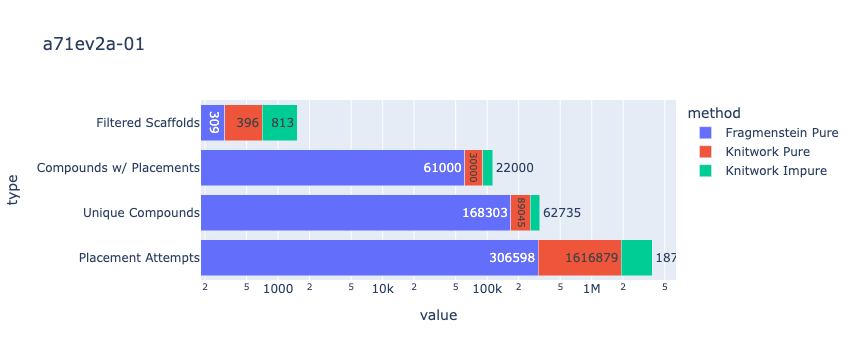

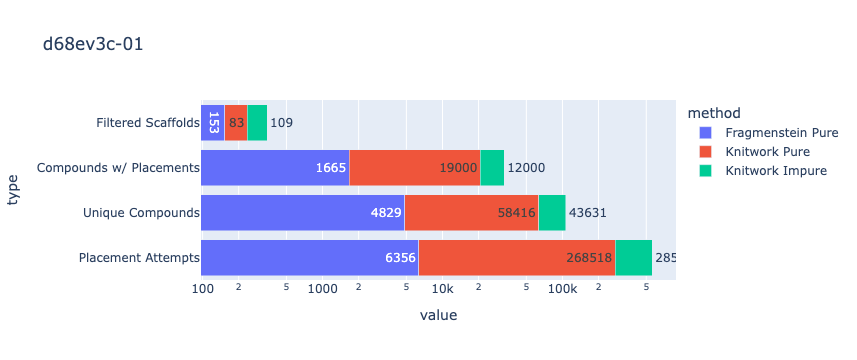

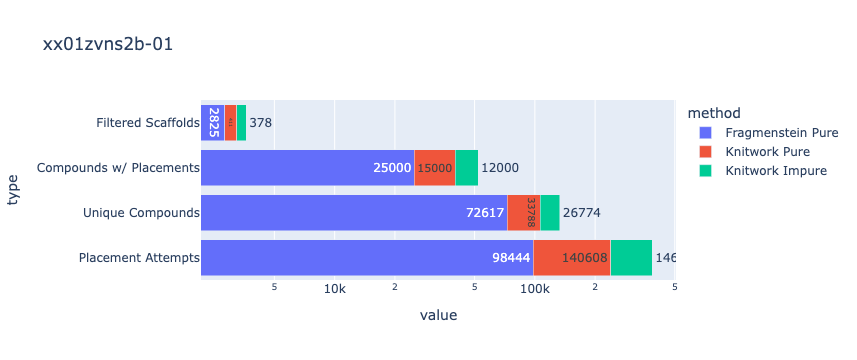

In [55]:
for cycle in set(df["cycle"].values):
    sdf = df[df["cycle"]==cycle]
    sdf = sdf[sdf["type"]!="Structures"]
    fig = px.bar(sdf, color="method", x="value", y="type", text="value", log_x=True, barmode="stack", title=cycle)
    display(fig)